# Exploratory Data Analysis — Iris Dataset

---

## Copyright and License

© 2026, Isabel Bejerano-Blazquez  
This Jupyter Notebook is licensed under the **MIT License**.

## Disclaimer

This notebook is provided "as is", without warranty of any kind, express or implied.  
The author assumes no responsibility or liability for any errors, omissions, or outcomes resulting from the use of this notebook or its contents.  
All analyses and interpretations are for **educational and research purposes only**.

## Dataset Note

**Dataset:** Iris — Multiclass Classification of Species (*Setosa / Versicolor / Virginica*)  
Locally under `../datasets/iris.csv`  
License: Public Domain

---

## Abstract

The Iris dataset is one of the most widely used benchmarks in supervised classification and exploratory data analysis. This notebook presents a structured EDA pipeline covering: data context, exploratory analysis, cleaning and validation, feature engineering, and class imbalance assessment.

## Executive Summary

The Iris dataset contains 150 samples across 3 balanced classes (50 each). Petal length and petal width are the strongest discriminators: *Iris setosa* is linearly separable from the other two species, while *versicolor* and *virginica* show partial overlap. Correlation analysis confirms high collinearity between petal dimensions (r=0.96). The dataset is clean, balanced, and well-suited for illustrating core EDA and preprocessing concepts.

---
## Setup & Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

%matplotlib inline
sns.set_theme(style='whitegrid', palette='Set2')
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Understanding Data Context

Knowing how, why, and where data was collected guides every subsequent decision: what cleaning is acceptable, what biases may exist, and what transformations make sense.

### The Iris Flower

The dataset measures 4 morphological features of iris flowers:

- **Sepal**: the outer, typically green leaf-like structures that protect the bud
- **Petal**: the inner, coloured structures that attract pollinators

Each sample records the **length** and **width** (in cm) of both sepals and petals.

![Iris flower anatomy](https://miro.medium.com/v2/resize:fit:2550/0*GVjzZeYrir0R_6-X.png)

### Dataset Overview

| Attribute | Detail |
|-----------|--------|
| **Origin** | Ronald A. Fisher (1936) — *The use of multiple measurements in taxonomic problems* |
| **Collection** | Physical measurements by Edgar Anderson, Gaspé Peninsula, Canada |
| **Purpose** | Demonstrate linear discriminant analysis for taxonomic classification |
| **Samples** | 150 (50 per species) |
| **Features** | 4 continuous morphological measurements (cm) |
| **Target** | Species: *Iris setosa*, *Iris versicolor*, *Iris virginica* |
| **License** | Public Domain |

### Features

| Feature | Description |
|---------|-------------|
| `sepal_length` | Length of the sepal (cm) |
| `sepal_width` | Width of the sepal (cm) |
| `petal_length` | Length of the petal (cm) |
| `petal_width` | Width of the petal (cm) |
| `species` | Target class label |

### Known Biases and Limitations

- Data collected from a single geographic location — limits generalisability.
- Only morphological features; no environmental or temporal variables.
- Perfectly balanced by design — atypical of real-world scenarios.
- *Versicolor* and *virginica* overlap in feature space, reflecting genuine biological variability.

In [2]:
COLUMNS  = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

df = pd.read_csv('../datasets/iris.csv', header=None, names=COLUMNS)

print(f'Shape: {df.shape}')
print(f'\nTarget distribution:\n{df["species"].value_counts()}')
df.head(10)

Shape: (150, 5)

Target distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [3]:
# Alternative: load Iris directly from scikit-learn (no local file needed)
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
#
# from sklearn.datasets import load_iris
#
# iris = load_iris(as_frame=True)
#
# df = iris.frame
# df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'label']
#
# # Map numeric labels back to species names
# label_map = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
# df['species'] = df['label'].map(label_map)
#
# print(f'Shape: {df.shape}')
# print(f'\nTarget distribution:\n{df["species"].value_counts()}')
# df.head(10)

---
## 2. Exploratory Data Analysis (EDA)

EDA discovers patterns, anomalies, outliers, and relationships using summary statistics and visualisations. It helps formulate hypotheses and spot issues before modelling.

### 2.1 Summary Statistics

In [4]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [5]:
print('--- Mean ---')
print(df.groupby('species')[FEATURES].mean().round(2))
print('\n--- Median ---')
print(df.groupby('species')[FEATURES].median().round(2))
print('\n--- Variance ---')
print(df.groupby('species')[FEATURES].var().round(3))

--- Mean ---
                 sepal_length  sepal_width  petal_length  petal_width
species                                                              
Iris-setosa              5.01         3.42          1.46         0.24
Iris-versicolor          5.94         2.77          4.26         1.33
Iris-virginica           6.59         2.97          5.55         2.03

--- Median ---
                 sepal_length  sepal_width  petal_length  petal_width
species                                                              
Iris-setosa               5.0          3.4          1.50          0.2
Iris-versicolor           5.9          2.8          4.35          1.3
Iris-virginica            6.5          3.0          5.55          2.0

--- Variance ---
                 sepal_length  sepal_width  petal_length  petal_width
species                                                              
Iris-setosa             0.124        0.145         0.030        0.011
Iris-versicolor         0.266        0.098 

### 2.2 Histograms

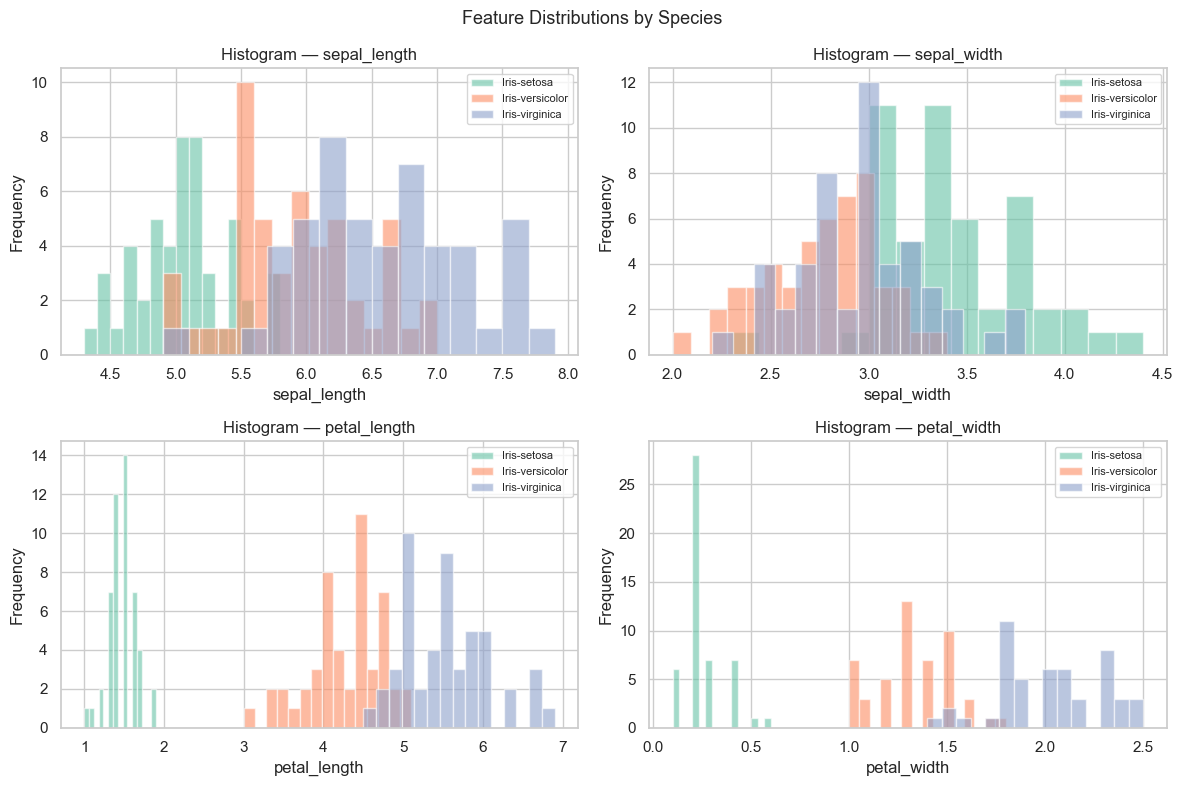

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), FEATURES):
    for species, group in df.groupby('species'):
        ax.hist(group[feature], bins=15, alpha=0.6, label=species)
    ax.set_title(f'Histogram — {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Species', fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Boxplots

/var/folders/_b/wh8hnvl133x175d6fkn5wh640000gn/T/ipykernel_6041/2424111733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='Set2')
/var/folders/_b/wh8hnvl133x175d6fkn5wh640000gn/T/ipykernel_6041/2424111733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='Set2')
/var/folders/_b/wh8hnvl133x175d6fkn5wh640000gn/T/ipykernel_6041/2424111733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='Set2'

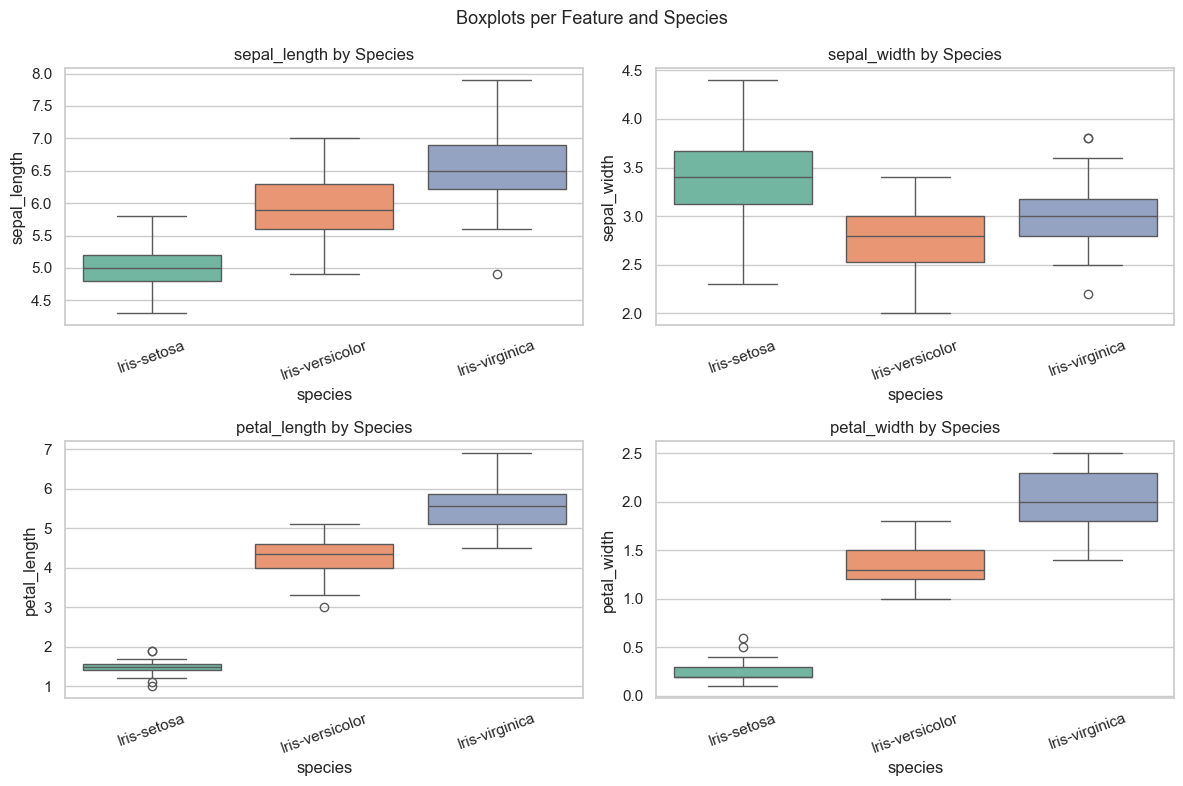

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), FEATURES):
    sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Species')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Boxplots per Feature and Species', fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Scatterplots — Pairplot

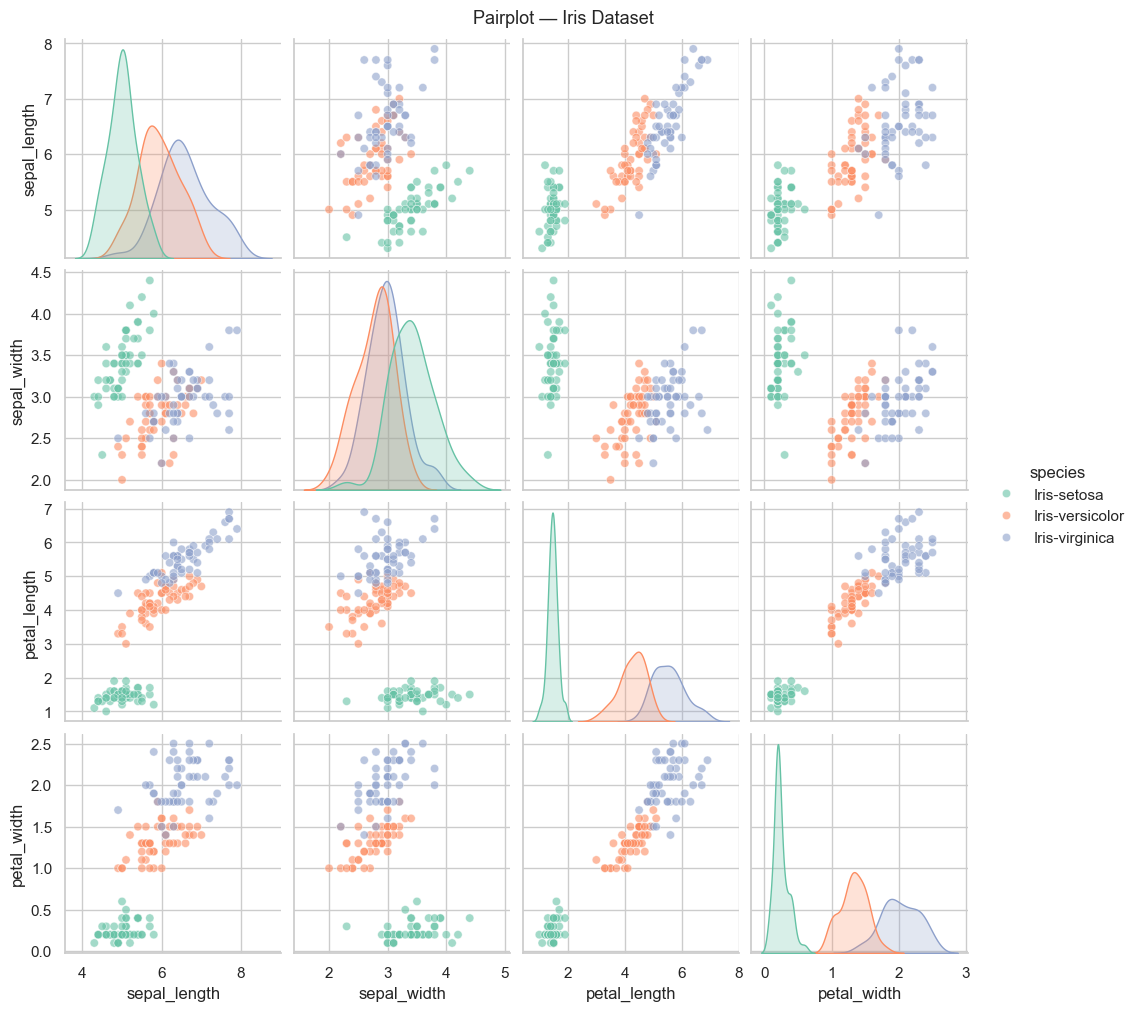

In [8]:
sns.pairplot(df[FEATURES + ['species']], hue='species', palette='Set2',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot — Iris Dataset', y=1.01, fontsize=13)
plt.show()

### 2.5 Correlation Matrix

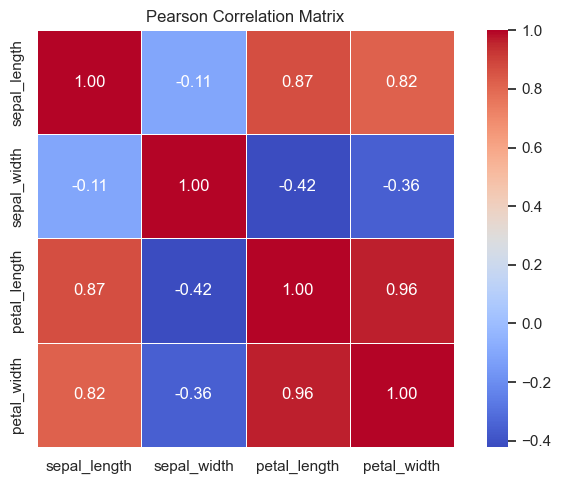

Key finding: petal_length and petal_width are highly correlated (r ≈ 0.96).


In [9]:
corr = df[FEATURES].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, square=True, linewidths=0.5)
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()
print('Key finding: petal_length and petal_width are highly correlated (r ≈ 0.96).')

---
## 3. Data Cleaning & Validation

Handle missing values, fix inconsistencies, remove duplicates, and ensure data integrity and type consistency.

### 3.1 Missing Values

In [10]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing: 0


No missing values in this dataset. In a real scenario, common strategies are:

| Strategy | When to use |
|----------|-------------|
| **Mean/median imputation** | Low missingness, numeric features |
| **Mode imputation** | Categorical features |
| **Predictive imputation** | High missingness, complex relationships |
| **Row removal** | Very few rows affected and data is abundant |

### 3.2 Duplicates

In [11]:
print(f'Duplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after deduplication: {df.shape}')

Duplicate rows: 3
Shape after deduplication: (147, 5)


### 3.3 Type Consistency & Outlier Detection

In [12]:
print('Data types:')
print(df.dtypes)

def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum()

print('\nOutliers per feature (IQR method):')
for f in FEATURES:
    print(f'  {f}: {count_outliers_iqr(df[f])}')

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

Outliers per feature (IQR method):
  sepal_length: 0
  sepal_width: 4
  petal_length: 0
  petal_width: 0


---
## 4. Feature Engineering & Processing

Transform features through scaling, encoding, and dimensionality reduction to improve model learning and reduce noise.

### 4.1 Encoding the Target Variable

In [13]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['species'])

print('Label encoding:')
for cls, lbl in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls} -> {lbl}')

X = df[FEATURES].values
y = df['label'].values

Label encoding:
  Iris-setosa -> 0
  Iris-versicolor -> 1
  Iris-virginica -> 2


### 4.2 Feature Scaling — StandardScaler

Standardisation (zero mean, unit variance) is required by distance-based and gradient-based algorithms.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=FEATURES)
print('Scaled feature statistics (mean≈0, std≈1):')
df_scaled.describe().loc[['mean', 'std']].round(3)

Scaled feature statistics (mean≈0, std≈1):


,sepal_length,sepal_width,petal_length,petal_width
mean,-0.000,0.000,-0.000,-0.000
std,1.003,1.003,1.003,1.003


### 4.3 Dimensionality Reduction — PCA

PCA reduces dimensionality by projecting data onto the directions of maximum variance.

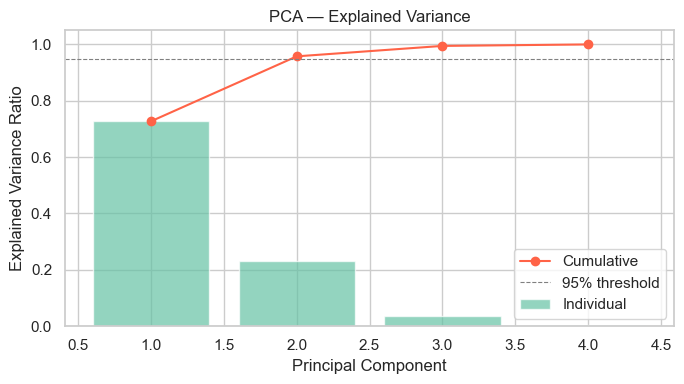

PC1 + PC2 explain 95.8% of total variance.


In [15]:
pca = PCA()
pca.fit(X_scaled)
explained  = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained) + 1), explained, alpha=0.7, label='Individual')
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o', color='tomato', label='Cumulative')
ax.axhline(0.95, linestyle='--', color='grey', linewidth=0.8, label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()
print(f'PC1 + PC2 explain {cumulative[1]:.1%} of total variance.')

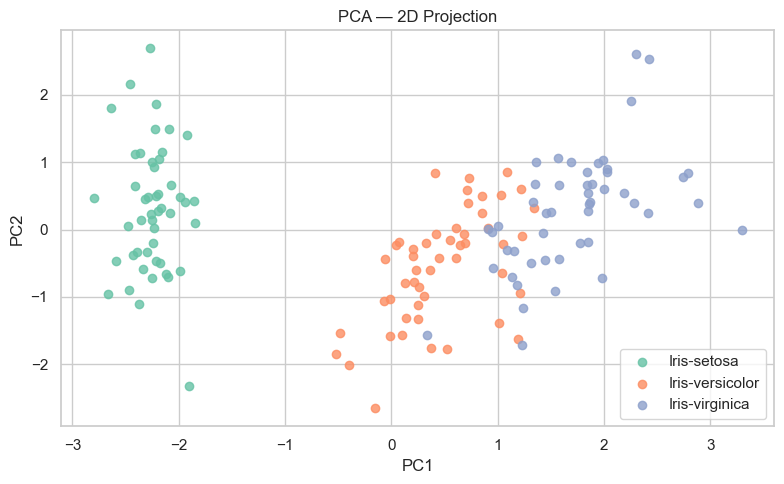

In [16]:
X_pca = PCA(n_components=2).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
for lbl, name in enumerate(le.classes_):
    mask = y == lbl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.8)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA — 2D Projection')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Dimensionality Reduction — LDA

LDA maximises class separability rather than variance — a supervised alternative to PCA.

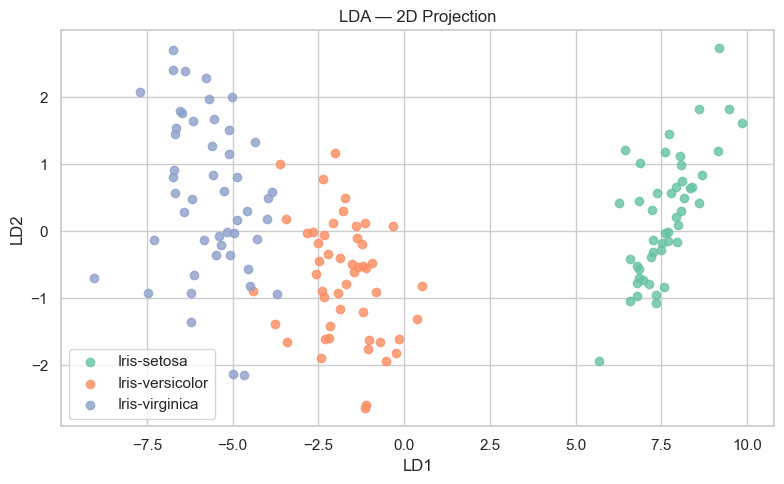

In [17]:
X_lda = LDA(n_components=2).fit_transform(X_scaled, y)

fig, ax = plt.subplots(figsize=(8, 5))
for lbl, name in enumerate(le.classes_):
    mask = y == lbl
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], label=name, alpha=0.8)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('LDA — 2D Projection')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Handling Imbalanced Data

Detect imbalance in class labels and understand strategies to address it.

### 5.1 Class Distribution

Class counts:
species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

Class proportions:
species
Iris-versicolor    0.340
Iris-virginica     0.333
Iris-setosa        0.327
Name: proportion, dtype: float64


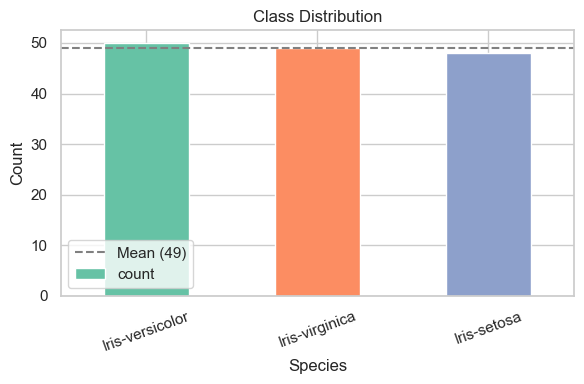

In [18]:
counts      = df['species'].value_counts()
proportions = df['species'].value_counts(normalize=True).round(3)

print('Class counts:')
print(counts)
print('\nClass proportions:')
print(proportions)

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', 3))
ax.axhline(counts.mean(), linestyle='--', color='grey', label=f'Mean ({counts.mean():.0f})')
ax.set_title('Class Distribution')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Imbalance Assessment

The Iris dataset is **perfectly balanced** (50 samples per class, 33.3% each). No resampling is needed here.

In real-world scenarios with imbalanced data, common strategies include:

| Strategy | Description | When to use |
|----------|-------------|-------------|
| **Oversampling (SMOTE)** | Synthesise new minority class samples | Minority class is underrepresented |
| **Undersampling** | Remove majority class samples | Large dataset, majority dominates |
| **Class weighting** | Penalise misclassification of minority class | Simple, no data modification needed |
| **Threshold tuning** | Adjust decision threshold post-training | When recall/precision trade-off matters |

### 5.3 Simulated Imbalance Example

Simulated imbalanced distribution:
species
Iris-setosa        48
Iris-versicolor    30
Iris-virginica     10
Name: count, dtype: int64


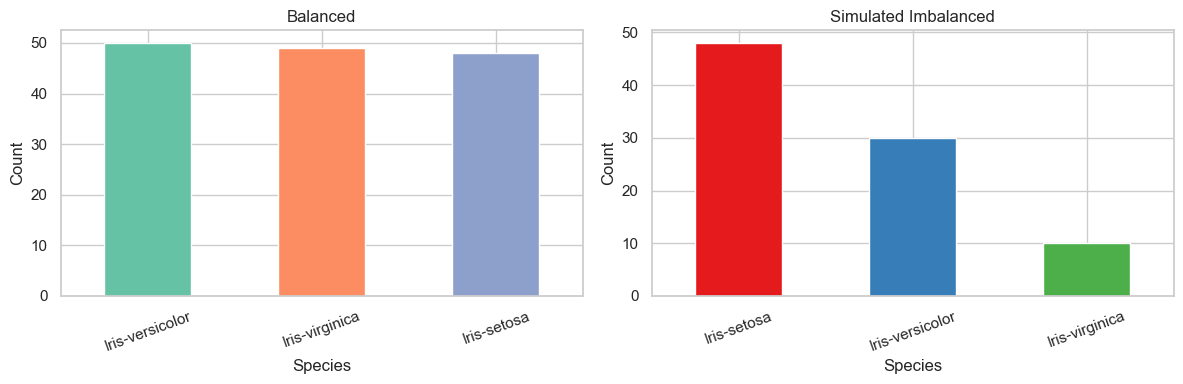

In [19]:
df_imbalanced = pd.concat([
    df[df['species'] == 'Iris-setosa'],
    df[df['species'] == 'Iris-versicolor'].sample(30, random_state=42),
    df[df['species'] == 'Iris-virginica'].sample(10, random_state=42)
]).reset_index(drop=True)

counts_imb = df_imbalanced['species'].value_counts()
print('Simulated imbalanced distribution:')
print(counts_imb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 3), title='Balanced')
counts_imb.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set1', 3), title='Simulated Imbalanced')
for ax in axes:
    ax.set_xlabel('Species')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

---
## Key Findings

| Topic | Finding |
|-------|---------|
| **Data context** | Single-location collection; perfectly balanced by design; only morphological features |
| **EDA** | Petal features are the strongest discriminators; sepal width shows weakest separation |
| **Cleaning** | No missing values; duplicate rows removed; minor outliers in sepal width |
| **Feature engineering** | StandardScaler applied; PC1+PC2 capture >95% variance; LDA achieves near-perfect class separation |
| **Class imbalance** | Dataset is balanced — no resampling required in practice |